In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 乱数のシードを固定（毎回同じデータが生成されるようにするため）
np.random.seed(42)

# ==========================================
# 1. パラメータの設定
# ==========================================
# サロゲートモデル用の「元データ（シミュレーション値や実験値の代わり）」の数
num_samples = 200

# 入力 X の範囲を指定（例： -π から +π まで）
x_min = -np.pi
x_max = np.pi

# ==========================================
# 2. データの生成（ラテン超方格サンプリングの簡易版：一様乱数）
# ==========================================
# データを特定の部分に偏らせず、万遍なく散らばるようにランダム生成します
# 深層学習モデルへの入力（X）は通常2次元配列 (サンプル数, 特徴量数) が期待されるため shape を (50, 1) にします
X_data = np.random.uniform(x_min, x_max, size=(num_samples, 1)).astype(np.float32)

# 正解データ（y）の計算 : y = sin(X)
# 出力も (サンプル数, 出力数) の形にするため shape を (50, 1) にします
y_data = np.sin(X_data).astype(np.float32)

# ==========================================
# 3. テスト・検証用のデータ（答え合わせ用）を別途作成
# ==========================================
# モデルが「データの間を綺麗に補間できているか」を確かめるため、
# 範囲内を等間隔に細かく区切った綺麗なデータ（100点）を別途用意します
X_test = np.linspace(x_min, x_max, 100).reshape(-1, 1).astype(np.float32)
y_test = np.sin(X_test).astype(np.float32)

print("--- データ作成完了 ---")
print(f"学習用データの形状  X_data: {X_data.shape}, y_data: {y_data.shape}")
print(f"検証用データの形状  X_test: {X_test.shape}, y_test: {y_test.shape}")

--- データ作成完了 ---
学習用データの形状  X_data: (200, 1), y_data: (200, 1)
検証用データの形状  X_test: (100, 1), y_test: (100, 1)


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import numpy as np


# 1. データの準備（お手元のデータを代入してください）
# X: shape(50, 10), y: shape(50, 2) を想定

X_data = np.array(X_data, dtype=np.float32)
y_data = np.array(y_data, dtype=np.float32)

# 標準化（これだけは精度を出すために必須です）
scaler_X, scaler_y = StandardScaler(), StandardScaler()
X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data)

# テンソル変換
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

# 2. 最もシンプルなモデル定義 (入力10 -> 隠れ層32 -> 出力2)
model = nn.Sequential(
    nn.Linear(1, 32), # ★ここを「20」にする
    nn.ReLU(),
    nn.Linear(32, 1)
)

# 3. 誤差関数と最適化の手法
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. 学習（500回まわす）
for epoch in range(500):
    optimizer.zero_grad()
    hypothesis = model(X_tensor)
    loss = criterion(hypothesis, y_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/500, Loss: {loss.item():.6f}")

print("学習完了！")

Epoch 100/500, Loss: 0.008939
Epoch 200/500, Loss: 0.000829
Epoch 300/500, Loss: 0.000268
Epoch 400/500, Loss: 0.000153
Epoch 500/500, Loss: 0.000122
学習完了！


=== サロゲートモデル 精度評価結果 ===
MSE (平均二乗誤差) : 2.624452
MAE (平均絶対誤差) : 1.274365
R2スコア (決定係数): -4.3019


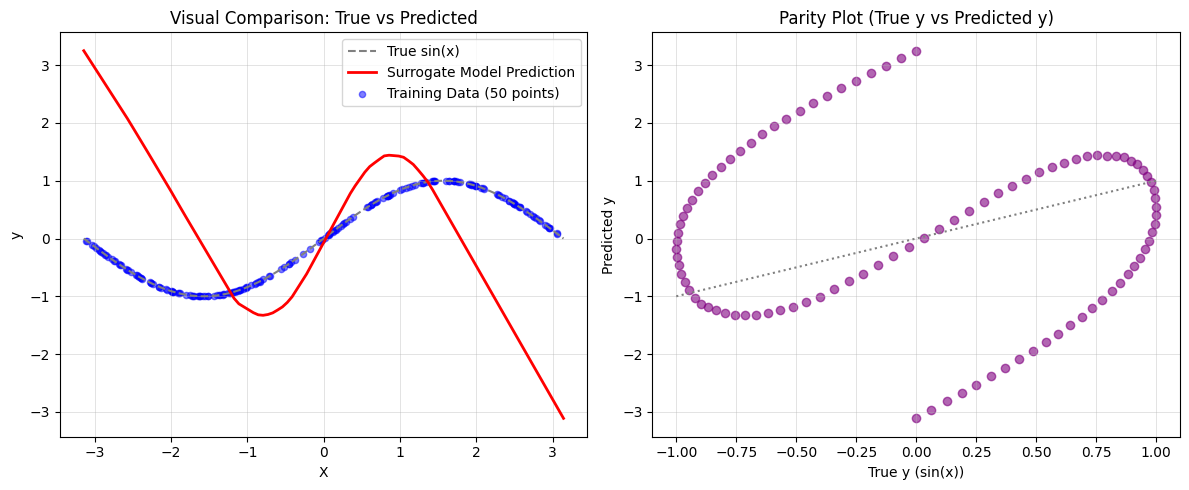

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. モデルにテストデータ(X_test)を入力して予測させる
# ==========================================
model.eval()  # 評価モードに切り替え

with torch.no_grad():
    # ※もし学習時にStandardScalerを使っていた場合は、ここで X_test も標準化し、
    # 予測された y_pred_scaled を inverse_transform で逆変換してください。
    # 今回は純粋なsin関数（-π〜π、-1〜1）なので、標準化なしの前提で進めます。

    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_pred_tensor = model(X_test_tensor)

    # 評価のために numpy 配列に変換
    y_pred = y_pred_tensor.numpy()

# ==========================================
# 2. 評価指標（数値）による比較
# ==========================================
print("=== サロゲートモデル 精度評価結果 ===")

# ① MSE (Mean Squared Error: 平均二乗誤差) -> 0に近いほど優秀
mse = mean_squared_error(y_test, y_pred)
print(f"MSE (平均二乗誤差) : {mse:.6f}")

# ② MAE (Mean Absolute Error: 平均絶対誤差) -> 0に近いほど優秀
mae = np.mean(np.abs(y_test - y_pred))
print(f"MAE (平均絶対誤差) : {mae:.6f}")

# ③ R2スコア (決定係数) -> 1に近づくほど完璧なモデル（0〜1の範囲が基本）
r2 = r2_score(y_test, y_pred)
print(f"R2スコア (決定係数): {r2:.4f}")


# ==========================================
# 3. グラフによる比較
# ==========================================
plt.figure(figsize=(12, 5))

# --- 左側のグラフ：フィッティングの比較 ---
plt.subplot(1, 2, 1)
plt.plot(X_test, y_test, label='True sin(x)', color='gray', linestyle='--')
plt.plot(X_test, y_pred, label='Surrogate Model Prediction', color='red', linewidth=2)
plt.scatter(X_data, y_data, color='blue', s=20, label='Training Data (50 points)', alpha=0.5)
plt.title('Visual Comparison: True vs Predicted')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# --- 右側のグラフ：パリティプロット（正解 vs 予測） ---
# 完璧なモデルなら、点がすべて y = x の対角線上に並びます
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, color='purple', alpha=0.6)
plt.plot([-1, 1], [-1, 1], color='gray', linestyle=':') # 対角線
plt.title('Parity Plot (True y vs Predicted y)')
plt.xlabel('True y (sin(x))')
plt.ylabel('Predicted y')
plt.grid(True)

plt.tight_layout()
plt.show()